In [1]:

import pandas as pd
import numpy as np

In [2]:
train='/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train'
test='/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/test'

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

2026-02-25 17:33:51.515516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772040831.699072      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772040831.757395      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772040832.210468      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772040832.210511      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772040832.210514      55 computation_placer.cc:177] computation placer alr

In [4]:
train_data=tf.keras.utils.image_dataset_from_directory(
    train,
    image_size=(224,224),
    batch_size=32
)

Found 2637 files belonging to 2 classes.


I0000 00:00:1772040929.637131      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
class_names=train_data.class_names

In [6]:
print(class_names)

['benign', 'malignant']


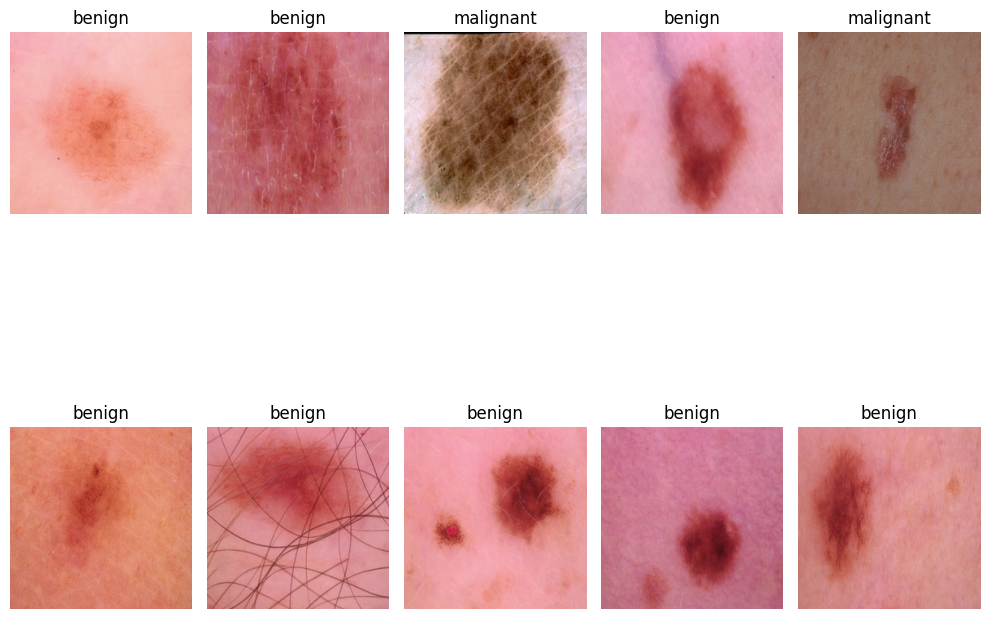

In [8]:
for image,label in train_data.take(1):
    plt.figure(figsize=(10,10))
    for i in range(10):
        ax=plt.subplot(2,5,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(class_names[label[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Dropout,BatchNormalization

In [39]:
from tensorflow.keras.models import Model

In [10]:
def random_contrast(img):
    factor=tf.random.uniform([],0.8,1.2)
    img=tf.image.adjust_contrast(img,factor)
    return img

In [12]:
train_aug=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    preprocessing_function=random_contrast,
    validation_split=0.2
)

In [47]:
target_size=(224,224)
batch_size=32
seed_value=123

In [48]:
train_generator=train_aug.flow_from_directory(
    train,
    target_size=target_size,
    batch_size=batch_size,
    seed=seed_value,
    class_mode='categorical',
    subset='training'
    
)

Found 2110 images belonging to 2 classes.


In [49]:
val_generator=train_aug.flow_from_directory(
    train,
    target_size=target_size,
    batch_size=batch_size,
    seed=seed_value,
    class_mode='categorical',
    subset='validation'
)

Found 527 images belonging to 2 classes.


In [50]:
test_ds=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0
)

In [51]:
test_generator=test_ds.flow_from_directory(
    test,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
    
)

Found 660 images belonging to 2 classes.


In [52]:
from tensorflow.keras.applications import DenseNet121

In [53]:
from tensorflow.keras import optimizers

In [54]:
from tensorflow.keras.layers import GlobalAveragePooling2D

In [55]:
base_model=DenseNet121(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False

In [56]:
from tensorflow.keras.callbacks import EarlyStopping

In [57]:
stop_early=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [58]:
num_classes=len(class_names)

In [64]:
x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(512,activation='relu')(x)
x=Dropout(0.4)(x)
output=Dense(num_classes,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)


In [65]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
step_per_epoch=train_generator.samples//batch_size
validation_steps=val_generator.samples//batch_size


In [66]:
history=model.fit(
    train_generator,
    steps_per_epoch=step_per_epoch,
    epochs=50,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=[stop_early]
)

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 79s 873ms/step - accuracy: 0.6958 - loss: 0.6652 - val_accuracy: 0.7891 - val_loss: 0.4281
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.8750 - loss: 0.3027 - val_accuracy: 0.8047 - val_loss: 0.4207
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 539ms/step - accuracy: 0.8333 - loss: 0.3694 - val_accuracy: 0.8340 - val_loss: 0.3958
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.8125 - loss: 0.3995 - val_accuracy: 0.8223 - val_loss: 0.4295
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 36s 561ms/step - accuracy: 0.8377 - loss: 0.3570 - val_accuracy: 0.8027 - val_loss: 0.4057
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.7188 - loss: 0.4311 - val_accuracy: 0.7930 - val_loss: 0.4289
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 36s 550ms/step - accuracy: 0.8346 - loss: 0.3424 - val_accuracy: 0.8145 - val_loss: 0.3935
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.7500 - loss: 0.4689 - val_accuracy

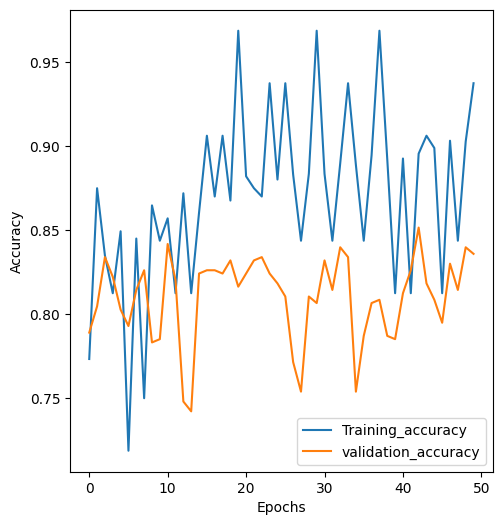

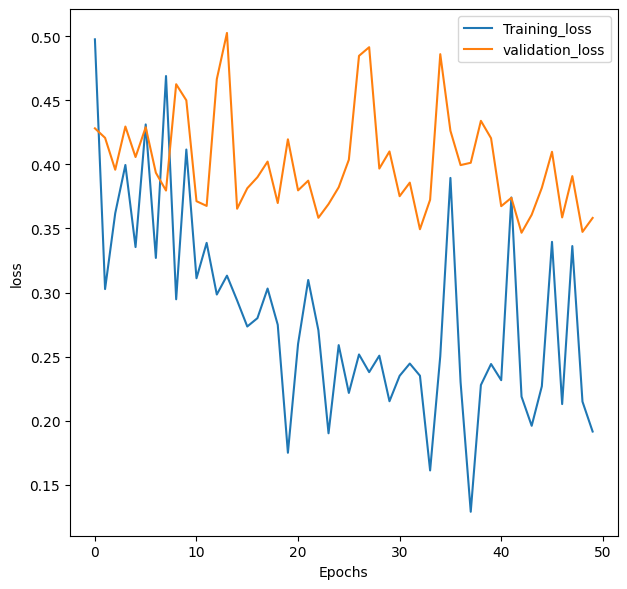

In [67]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label=['Training_accuracy'])
plt.plot(history.history['val_accuracy'],label=['validation_accuracy'])
plt.xlabel('Epochs')
plt.ylabel("Accuracy")
plt.legend()

plt.figure(figsize=(12,6))
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label=['Training_loss'])
plt.plot(history.history['val_loss'],label=['validation_loss'])
plt.xlabel('Epochs')
plt.ylabel("loss")
plt.legend()

plt.tight_layout()
plt.show()

In [68]:
from sklearn.metrics import classification_report,confusion_matrix

21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 916ms/step


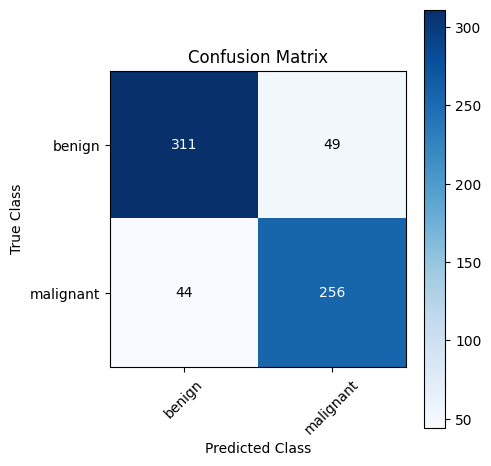

Classification Report:
              precision    recall  f1-score   support

      benign       0.88      0.86      0.87       360
   malignant       0.84      0.85      0.85       300

    accuracy                           0.86       660
   macro avg       0.86      0.86      0.86       660
weighted avg       0.86      0.86      0.86       660



In [69]:
y_true = test_generator.classes
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(5, 5))
plt.imshow(conf_matrix, cmap="Blues", interpolation="nearest")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, test_generator.class_indices, rotation=45)
plt.yticks(tick_marks, test_generator.class_indices)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

# Annotate the cells with the values
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(conf_matrix[i, j]),
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices))

In [70]:
for layer in reversed(model.layers):
    if 'conv' in layer.name and 'Conv2D' in str(layer.__class__):
        print("Last conv layer:", layer.name)
        break

Last conv layer: conv5_block16_2_conv


In [80]:
class_names = ["benign", "malignant"]  # index 0 → benign, 1 → malignant

In [87]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.densenet import preprocess_input
import cv2
import matplotlib.pyplot as plt

def grad_cam(model, img_path, class_names, last_conv_layer_name="conv5_block16_2_conv", alpha=0.4):
    """
    Grad-CAM visualization with class name output.
    """
    # Load & preprocess image
    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # Create model that outputs conv layer + predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute gradient
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([x])  # ✅ pass as list
        predicted_class = tf.argmax(predictions[0])
        loss = predictions[:, predicted_class]

    # Print class name
    print(f"Image: {img_path} → Predicted class: {class_names[predicted_class]}")

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    # Load original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))

    # Resize heatmap
    heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

    # Display
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

Image: /kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/benign/100.jpg → Predicted class: benign


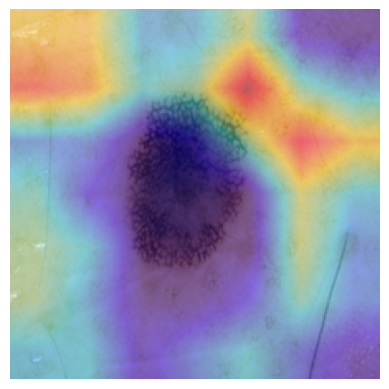

Image: /kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/benign/1000.jpg → Predicted class: benign


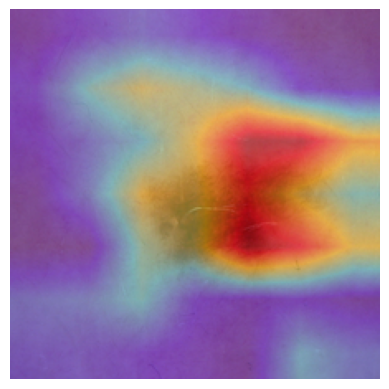

Image: /kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/benign/1001.jpg → Predicted class: benign


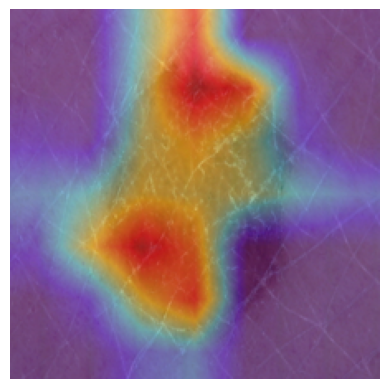

Image: /kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/malignant/10.jpg → Predicted class: malignant


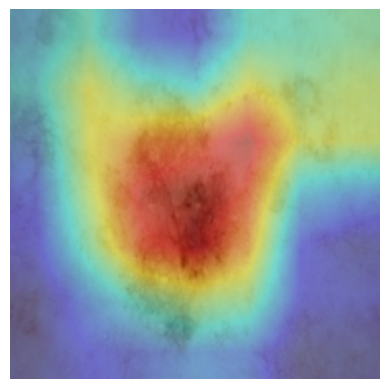

Image: /kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/malignant/1000.jpg → Predicted class: malignant


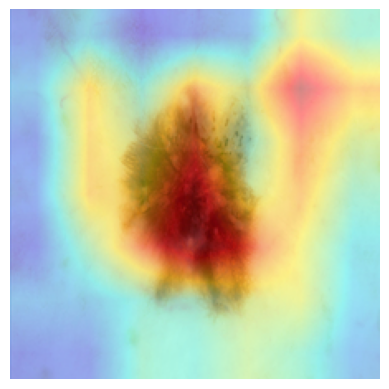

Image: /kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/malignant/1001.jpg → Predicted class: benign


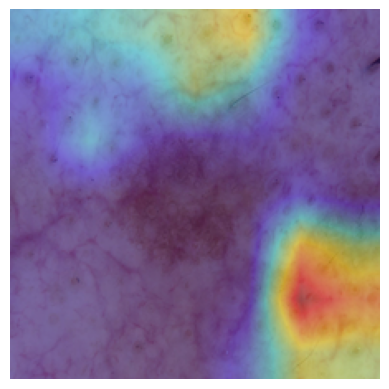

In [88]:
image_paths = [
    "/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/benign/100.jpg",
    "/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/benign/1000.jpg",
    "/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/benign/1001.jpg",
    "/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/malignant/10.jpg",
    "/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/malignant/1000.jpg",
    "/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train/malignant/1001.jpg"
    
]

for img_path in image_paths:
    grad_cam(model, img_path,class_names)